# <font color='#000000'>__Exercício Prático 1__</font>
## <font color='#1c8a23'>Interação com API’s – Football-Data.org </font>
#### <font color='#4b4b4b'>Master Big Data Aplicado ao Futebol <br> Módulo 5 - Análise de dados no futebol com Python <br> Desenvolvido por: Hugo Alves </font>

__Enunciado do Exercício__

<i> Usando a API da Football Data, pretende-se que descarreguem toda a informação dos jogos de uma competição à vossa escolha, usando o endpoint: "http://api.football-data.org/v4/competitions/{id}/matches"

Com base na informação descarregada queremos saber quais são as melhores equipas a segurar resultados em casa (ganhar ao intervalo e ganhar no final) e as que melhores a virar o resultado na 2ª parte, independentemente de ser em casa ou fora. <br>
Para ambos os casos interessa nos saber não só a quantidade de vezes que o fizeram mas principalmente a percentagem de resultados virados / mantidos.

Bónus: Tendo chegado até aqui, será que conseguimos calcular a tabela classificativa dessa liga? Para tal contabilizemos cada vitória com 3 pontos, empate com 1 e derrota com 0. Há alguma relação entre as equipas de topo e as métricas que calculámos anteriormente? </i>

# <font color="#1c8a23">___________________</font>
## <font color="#4b4b4b">Índice de Conteúdos</font> <a class="anchor" id="toc"></a>
[1. Setup Inicial](#setup)<br>
- [1.1. Importações](#imps)<br>
- [1.2. Ligação à API - Football-Data.org](#api)<br>

[2. Preparação e Pré-Processamento dos Dados](#prep)<br>

[3. Análise](#analise)<br>
- [3.1. Segurar Resultados Enquanto Visitado](#segurar)<br>
- [3.2. Virar Resultados na Segunda Parte](#virar)<br>

[4. Bónus - Comparação com Classificação Final](#bonus)<br>

# <font color="#1c8a23">______________</font>
## <font color='#4b4b4b'>1. Setup Inicial</font> <a class="anchor" id="setup"></a>
[Regressar ao Índice](#toc)

### <font color='#1c8a23'>1.1. Importações</font> <a class="anchor" id="imps"></a>
[Regressar ao Índice](#toc)

In [1]:
#!python --version

Vamos utilizar a versão 3.11.8 do Python.

Abaixo encontram-se os packages que podem precisar de instalação. Se for necessário instalar algum, basta descomentar a respetiva linha.

In [2]:
#!pip install numpy==1.26.4
#!pip install pandas==2.2.1
#!pip install matplotlib==3.8.0
#!pip install requests==2.31.0
#!pip install json==2.0.9
#!pip install PIL==10.2.0
#!pip install plottable==0.1.5
#!pip install seaborn==0.12.2

In [3]:
# Importar as bibliotecas necessárias
%run Imports
# Importar as funções criadas no módulo Functions.py
import Functions as fn

### <font color='#1c8a23'>1.2. Ligação à API - Football-Data.org</font> <a class="anchor" id="api"></a>
[Regressar ao Índice](#toc)

Nesta parte, vamos ligar-nos à API [football-data.org](https://www.football-data.org/) para obter os dados deste exercício. Para avançar, é necessário criar conta para obter uma chave de autenticação que permite até 10 chamadas à API por minuto.

A documentação da API encontra-se disponível [aqui](https://www.football-data.org/documentation/quickstart).

In [4]:
headers = {"X-Auth-Token": "329dac0206a14a7b9a64ff4e4b51f928"}

Vamos começar por olhar para as competições disponíveis, antes de decidir por qual optar.

In [5]:
url_comps = "http://api.football-data.org/v4/competitions/"
response_comps = requests.get(url_comps, headers = headers)

comps = json.loads(response_comps.text)
comps

{'count': 13,
 'filters': {'client': 'Hugo'},
 'competitions': [{'id': 2013,
   'area': {'id': 2032,
    'name': 'Brazil',
    'code': 'BRA',
    'flag': 'https://crests.football-data.org/764.svg'},
   'name': 'Campeonato Brasileiro Série A',
   'code': 'BSA',
   'type': 'LEAGUE',
   'emblem': 'https://crests.football-data.org/bsa.png',
   'plan': 'TIER_ONE',
   'currentSeason': {'id': 2474,
    'startDate': '2026-01-28',
    'endDate': '2026-12-02',
    'currentMatchday': 3,
    'winner': None},
   'numberOfAvailableSeasons': 10,
   'lastUpdated': '2024-09-13T16:55:53Z'},
  {'id': 2016,
   'area': {'id': 2072,
    'name': 'England',
    'code': 'ENG',
    'flag': 'https://crests.football-data.org/770.svg'},
   'name': 'Championship',
   'code': 'ELC',
   'type': 'LEAGUE',
   'emblem': 'https://crests.football-data.org/ELC.png',
   'plan': 'TIER_ONE',
   'currentSeason': {'id': 2416,
    'startDate': '2025-08-08',
    'endDate': '2026-12-29',
    'currentMatchday': 32,
    'winner': No

In [6]:
# Converter para DataFrame para facilitar a análise
df_comps = pd.json_normalize(comps["competitions"])
df_comps.head()

,id,name,code,type,emblem,plan,numberOfAvailableSeasons,lastUpdated,area.id,area.name,area.code,area.flag,currentSeason.id,currentSeason.startDate,currentSeason.endDate,currentSeason.currentMatchday,currentSeason.winner,currentSeason.winner.id,currentSeason.winner.name,currentSeason.winner.shortName,currentSeason.winner.tla,currentSeason.winner.crest,currentSeason.winner.address,currentSeason.winner.website,currentSeason.winner.founded,currentSeason.winner.clubColors,currentSeason.winner.venue,currentSeason.winner.lastUpdated
0,2013,Campeonato Brasileiro Série A,BSA,LEAGUE,https://crests.football-data.org/bsa.png,TIER_ONE,10,2024-09-13T16:55:53Z,2032,Brazil,BRA,https://crests.football-data.org/764.svg,2474,2026-01-28,2026-12-02,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016,Championship,ELC,LEAGUE,https://crests.football-data.org/ELC.png,TIER_ONE,9,2024-09-13T16:51:18Z,2072,England,ENG,https://crests.football-data.org/770.svg,2416,2025-08-08,2026-12-29,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,Premier League,PL,LEAGUE,https://crests.football-data.org/PL.png,TIER_ONE,127,2024-09-13T16:51:24Z,2072,England,ENG,https://crests.football-data.org/770.svg,2403,2025-08-15,2026-05-24,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001,UEFA Champions League,CL,CUP,https://crests.football-data.org/CL.png,TIER_ONE,46,2024-09-13T16:53:48Z,2077,Europe,EUR,https://crests.football-data.org/EUR.svg,2454,2025-09-16,2026-05-30,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,European Championship,EC,CUP,https://crests.football-data.org/ec.png,TIER_ONE,17,2024-09-13T17:04:30Z,2077,Europe,EUR,https://crests.football-data.org/EUR.svg,1537,2024-06-14,2024-07-14,7,NaN,760.0,Spain,Spain,ESP,https://crests.football-data.org/760.svg,"Ramón y Cajal, s/n Las Rozas 28230",http://www.rfef.es,1909.0,Red / Blue / Yellow,Estadio Alfredo Di Stéfano,2021-05-26T09:46:48Z


In [7]:
# Listar as competições disponíveis
df_comps["name"].unique().tolist()

['Campeonato Brasileiro Série A',
 'Championship',
 'Premier League',
 'UEFA Champions League',
 'European Championship',
 'Ligue 1',
 'Bundesliga',
 'Serie A',
 'Eredivisie',
 'Primeira Liga',
 'Copa Libertadores',
 'Primera Division',
 'FIFA World Cup']

Para o propósito do exercício, o mais indicado será escolher uma liga e não um torneio. Dentro das ligas disponíveis, a Bundesliga é aquela que tendencialmente apresenta uma média de golos superior (algo que se verificou, por exemplo, em [2024/25](https://statsultra.com/goal-difference-vs-head-to-head-tiebreaker/)) e, nesta perspetiva, pode ser interessante avaliar se estes golos são marcados por equipas que viram resultados, ou por equipas que ampliam a sua vantagem nas partidas.

In [8]:
df_comps[df_comps["name"] == "Bundesliga"]

,id,name,code,type,emblem,plan,numberOfAvailableSeasons,lastUpdated,area.id,area.name,area.code,area.flag,currentSeason.id,currentSeason.startDate,currentSeason.endDate,currentSeason.currentMatchday,currentSeason.winner,currentSeason.winner.id,currentSeason.winner.name,currentSeason.winner.shortName,currentSeason.winner.tla,currentSeason.winner.crest,currentSeason.winner.address,currentSeason.winner.website,currentSeason.winner.founded,currentSeason.winner.clubColors,currentSeason.winner.venue,currentSeason.winner.lastUpdated
6,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,TIER_ONE,63,2024-09-13T16:48:00Z,2088,Germany,DEU,https://crests.football-data.org/759.svg,2414,2025-08-22,2026-05-16,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vamos então buscar mais informação sobre os jogos desta liga, aplicando o filtro `season={YEAR}` para obter apenas os jogos da época 2024/25 (que começou em 2024).

In [9]:
url_bl_matches = "http://api.football-data.org/v4/competitions/2002/matches?season=2024"
response_bl_matches = requests.get(url_bl_matches, headers = headers)

bl_matches = json.loads(response_bl_matches.text)
bl_matches

{'filters': {'season': 2024},
 'resultSet': {'count': 306,
  'first': '2024-08-23',
  'last': '2025-05-17',
  'played': 306},
 'competition': {'id': 2002,
  'name': 'Bundesliga',
  'code': 'BL1',
  'type': 'LEAGUE',
  'emblem': 'https://crests.football-data.org/BL1.png'},
 'matches': [{'area': {'id': 2088,
    'name': 'Germany',
    'code': 'DEU',
    'flag': 'https://crests.football-data.org/759.svg'},
   'competition': {'id': 2002,
    'name': 'Bundesliga',
    'code': 'BL1',
    'type': 'LEAGUE',
    'emblem': 'https://crests.football-data.org/BL1.png'},
   'season': {'id': 2308,
    'startDate': '2024-08-23',
    'endDate': '2025-05-17',
    'currentMatchday': 34,
    'winner': {'id': 5,
     'name': 'FC Bayern München',
     'shortName': 'Bayern',
     'tla': 'FCB',
     'crest': 'https://crests.football-data.org/5.png',
     'address': 'Säbenerstr. 51 München 81547',
     'website': 'http://www.fcbayern.de',
     'founded': 1900,
     'clubColors': 'Red / White / Blue',
     'ven

In [10]:
df_bundesliga = pd.json_normalize(bl_matches["matches"])
df_bundesliga.head()

,id,utcDate,status,matchday,stage,group,lastUpdated,referees,area.id,area.name,area.code,area.flag,competition.id,competition.name,competition.code,competition.type,competition.emblem,season.id,season.startDate,season.endDate,season.currentMatchday,season.winner.id,season.winner.name,season.winner.shortName,season.winner.tla,season.winner.crest,season.winner.address,season.winner.website,season.winner.founded,season.winner.clubColors,season.winner.venue,season.winner.lastUpdated,homeTeam.id,homeTeam.name,homeTeam.shortName,homeTeam.tla,homeTeam.crest,awayTeam.id,awayTeam.name,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.duration,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away,odds.msg
0,502371,2024-08-23T18:30:00Z,FINISHED,1,REGULAR_SEASON,None,2025-06-27T16:59:01Z,"[{'id': 57519, 'name': 'Robert Schröder', 'typ...",2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,18,Borussia Mönchengladbach,M'gladbach,BMG,https://crests.football-data.org/18.png,3,Bayer 04 Leverkusen,Leverkusen,B04,https://crests.football-data.org/3.png,AWAY_TEAM,REGULAR,2,3,0.0,2.0,Activate Odds-Package in User-Panel to retriev...
1,502372,2024-08-24T13:30:00Z,FINISHED,1,REGULAR_SEASON,None,2025-06-27T16:59:01Z,"[{'id': 43922, 'name': 'Benjamin Brand', 'type...",2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,721,RB Leipzig,RB Leipzig,RBL,https://crests.football-data.org/721.png,36,VfL Bochum 1848,Bochum,BOC,https://crests.football-data.org/36.png,HOME_TEAM,REGULAR,1,0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...
2,502374,2024-08-24T13:30:00Z,FINISHED,1,REGULAR_SEASON,None,2025-06-27T16:59:01Z,"[{'id': 43943, 'name': 'Tobias Stieler', 'type...",2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,2,TSG 1899 Hoffenheim,Hoffenheim,TSG,https://crests.football-data.org/2.png,720,Holstein Kiel,Holstein Kiel,KSV,https://crests.football-data.org/720.png,HOME_TEAM,REGULAR,3,2,2.0,0.0,Activate Odds-Package in User-Panel to retriev...
3,502375,2024-08-24T13:30:00Z,FINISHED,1,REGULAR_SEASON,None,2025-06-27T16:59:01Z,"[{'id': 57539, 'name': 'Tobias Welz', 'type': ...",2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,17,SC Freiburg,Freiburg,SCF,https://crests.football-data.org/17.png,10,VfB Stuttgart,Stuttgart,VFB,https://crests.football-data.org/10.png,HOME_TEAM,REGULAR,3,1,1.0,1.0,Activate Odds-Package in User-Panel to retriev...
4,502376,2024-08-24T13:30:00Z,FINISHED,1,REGULAR_SEASON,None,2025-06-27T16:59:01Z,"[{'id': 9567, 'name': 'Sascha Stegemann', 'typ...",2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07

# <font color="#1c8a23">___________________________________________</font>
## <font color='#4b4b4b'>2. Preparação e Pré-Processamento dos Dados</font> <a class="anchor" id="prep"></a>
[Regressar ao Índice](#toc)

Antes de avançar para a manipulação dos dados e validações mais específicas, vamos fazer um quality check para garantir que temos tudo (e apenas) aquilo que precisamos.

In [11]:
print("Os jogos foram disputados entre {} e {}.".format(df_bundesliga["utcDate"].min(), df_bundesliga["utcDate"].max()))
print("Temos {} linhas no dataset.".format(df_bundesliga.shape[0]))
print("Ao longo da temporada, foram disputados {} jogos.".format(df_bundesliga["id"].nunique()))
print("A média de golos por jogo nesta temporada foi de {:.2f}.".format(
    (df_bundesliga["score.fullTime.home"].sum() + df_bundesliga["score.fullTime.away"].sum()) / df_bundesliga.shape[0]))

Os jogos foram disputados entre 2024-08-23T18:30:00Z e 2025-05-17T13:30:00Z.
Temos 306 linhas no dataset.
Ao longo da temporada, foram disputados 306 jogos.
A média de golos por jogo nesta temporada foi de 3.13.


As datas dos jogos disputados correspondem ao esperado para a época (e aos valores das colunas `season.startDate` e `season.endDate`). Temos também 306 linhas no dataset, que correspondem por sua vez a 306 jogos distintos e ao valor esperado de 9 jogos por jornada x 34 jornadas. <br>
Por fim, a média de golos por jogo foi 3.13, alinhado com o que esperávamos encontrar e com os valores apresentados no artigo acima referido.

Podemos descartar desde já algumas colunas, visto que não planeamos fazer nada com a informação dos árbitros ou com as odds da partida, por exemplo.

In [12]:
df_bundesliga.drop(columns = {"referees", "odds.msg"}, inplace = True)

# Verificar que outras colunas apresentam valores únicos (e pouco relevantes)
print("Valores únicos para a coluna 'status':\n", df_bundesliga["status"].unique(), "\n")
print("Valores únicos para a coluna 'stage':\n", df_bundesliga["stage"].unique(), "\n")
print("Valores únicos para a coluna 'group':\n", df_bundesliga["group"].unique(), "\n")
print("Valores únicos para a coluna 'lastUpdated':\n", df_bundesliga["lastUpdated"].unique(), "\n")
print("Valores únicos para a coluna 'score.duration':\n", df_bundesliga["score.duration"].unique(), "\n")

Valores únicos para a coluna 'status':
 ['FINISHED' 'AWARDED'] 

Valores únicos para a coluna 'stage':
 ['REGULAR_SEASON'] 

Valores únicos para a coluna 'group':
 [None] 

Valores únicos para a coluna 'lastUpdated':
 ['2025-06-27T16:59:01Z'] 

Valores únicos para a coluna 'score.duration':
 ['REGULAR'] 



Não esperávamos um valor diferente na coluna `status`. Vamos ver o que se passou.

In [13]:
df_bundesliga[df_bundesliga["status"] == "AWARDED"]

,id,utcDate,status,matchday,stage,group,lastUpdated,area.id,area.name,area.code,area.flag,competition.id,competition.name,competition.code,competition.type,competition.emblem,season.id,season.startDate,season.endDate,season.currentMatchday,season.winner.id,season.winner.name,season.winner.shortName,season.winner.tla,season.winner.crest,season.winner.address,season.winner.website,season.winner.founded,season.winner.clubColors,season.winner.venue,season.winner.lastUpdated,homeTeam.id,homeTeam.name,homeTeam.shortName,homeTeam.tla,homeTeam.crest,awayTeam.id,awayTeam.name,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.duration,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away
120,502494,2024-12-14T14:30:00Z,AWARDED,14,REGULAR_SEASON,None,2025-06-27T16:59:01Z,2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,28,1. FC Union Berlin,Union Berlin,UNB,https://crests.football-data.org/28.png,36,VfL Bochum 1848,Bochum,BOC,https://crests.football-data.org/36.png,AWAY_TEAM,REGULAR,0,2,NaN,NaN


Esta partida foi jogada a 14/12/2024 entre o Union Berlin e o Bochum, mas foi interrompida (com 1-1 no marcador, na altura) após o guarda-redes visitante ser atingido por uma tocha. [O Bochum acabou por ganhar 2-0 na secretaria e levar os 3 pontos](https://www.bundesliga.com/en/bundesliga/news/dfb-rules-in-favour-of-bochum-win-union-berlin-lighter-hit-player-appeal-30346).

"Felizmente", dado que este jogo estava empatado ao intervalo, este caso não se enquadraria em nenhum dos cenários aqui em análise independentemente do resultado final: segurar o resultado em casa (ganhar ao intervalo e ganhar no final) ou virar o resultado na 2ª parte. Assim, vamos optar por manter este jogo no dataset e vamos imputar o resultado que efetivamente se verificava ao intevalo, com um golo para cada lado.

In [14]:
df_bundesliga.loc[df_bundesliga["id"] == 502494, ["score.halfTime.home", "score.halfTime.away"]] = 1
df_bundesliga[df_bundesliga["status"] == "AWARDED"]

,id,utcDate,status,matchday,stage,group,lastUpdated,area.id,area.name,area.code,area.flag,competition.id,competition.name,competition.code,competition.type,competition.emblem,season.id,season.startDate,season.endDate,season.currentMatchday,season.winner.id,season.winner.name,season.winner.shortName,season.winner.tla,season.winner.crest,season.winner.address,season.winner.website,season.winner.founded,season.winner.clubColors,season.winner.venue,season.winner.lastUpdated,homeTeam.id,homeTeam.name,homeTeam.shortName,homeTeam.tla,homeTeam.crest,awayTeam.id,awayTeam.name,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.duration,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away
120,502494,2024-12-14T14:30:00Z,AWARDED,14,REGULAR_SEASON,None,2025-06-27T16:59:01Z,2088,Germany,DEU,https://crests.football-data.org/759.svg,2002,Bundesliga,BL1,LEAGUE,https://crests.football-data.org/BL1.png,2308,2024-08-23,2025-05-17,34,5,FC Bayern München,Bayern,FCB,https://crests.football-data.org/5.png,Säbenerstr. 51 München 81547,http://www.fcbayern.de,1900,Red / White / Blue,Allianz Arena,2024-07-09T17:26:37Z,28,1. FC Union Berlin,Union Berlin,UNB,https://crests.football-data.org/28.png,36,VfL Bochum 1848,Bochum,BOC,https://crests.football-data.org/36.png,AWAY_TEAM,REGULAR,0,2,1.0,1.0


Podemos finalmente apagar estas colunas.

In [15]:
df_bundesliga.drop(columns = {"status", "stage", "group", "lastUpdated", "score.duration"}, inplace = True)

Existem ainda outras variáveis que são constantes ao longo de todo o dataset, em especial aquelas que dizem respeito aos grupos `area` e `season`. Não vamos utilizar estes dados para nada no seu formato tabular, mas pode ser interessante manter pelo menos parte desta informação para eventuais análises futuras. Por isso, vamos guardar alguns destes valores em variáveis e apagar as colunas, de modo a limpar mais o dataset para o nosso propósito.

In [16]:
# Garantir que só há de facto um valor por coluna, para não termos mais surpresas
colunas_unicas = [col for col in df_bundesliga.columns if col.startswith(("area.", "competition.", "season."))]
df_bundesliga[colunas_unicas].nunique()

area.id                      1
area.name                    1
area.code                    1
area.flag                    1
competition.id               1
competition.name             1
competition.code             1
competition.type             1
competition.emblem           1
season.id                    1
season.startDate             1
season.endDate               1
season.currentMatchday       1
season.winner.id             1
season.winner.name           1
season.winner.shortName      1
season.winner.tla            1
season.winner.crest          1
season.winner.address        1
season.winner.website        1
season.winner.founded        1
season.winner.clubColors     1
season.winner.venue          1
season.winner.lastUpdated    1
dtype: int64

In [17]:
# Podemos guardar tudo num dicionário e vir buscar a informação se/quando vier a ser útil
bundesliga_metadados = (df_bundesliga[colunas_unicas].iloc[0].to_dict())
bundesliga_metadados

{'area.id': 2088,
 'area.name': 'Germany',
 'area.code': 'DEU',
 'area.flag': 'https://crests.football-data.org/759.svg',
 'competition.id': 2002,
 'competition.name': 'Bundesliga',
 'competition.code': 'BL1',
 'competition.type': 'LEAGUE',
 'competition.emblem': 'https://crests.football-data.org/BL1.png',
 'season.id': 2308,
 'season.startDate': '2024-08-23',
 'season.endDate': '2025-05-17',
 'season.currentMatchday': 34,
 'season.winner.id': 5,
 'season.winner.name': 'FC Bayern München',
 'season.winner.shortName': 'Bayern',
 'season.winner.tla': 'FCB',
 'season.winner.crest': 'https://crests.football-data.org/5.png',
 'season.winner.address': 'Säbenerstr. 51 München 81547',
 'season.winner.website': 'http://www.fcbayern.de',
 'season.winner.founded': 1900,
 'season.winner.clubColors': 'Red / White / Blue',
 'season.winner.venue': 'Allianz Arena',
 'season.winner.lastUpdated': '2024-07-09T17:26:37Z'}

In [18]:
# Apagar as colunas do dataset
df_bundesliga.drop(columns = colunas_unicas, inplace = True)
df_bundesliga.head()

,id,utcDate,matchday,homeTeam.id,homeTeam.name,homeTeam.shortName,homeTeam.tla,homeTeam.crest,awayTeam.id,awayTeam.name,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away
0,502371,2024-08-23T18:30:00Z,1,18,Borussia Mönchengladbach,M'gladbach,BMG,https://crests.football-data.org/18.png,3,Bayer 04 Leverkusen,Leverkusen,B04,https://crests.football-data.org/3.png,AWAY_TEAM,2,3,0.0,2.0
1,502372,2024-08-24T13:30:00Z,1,721,RB Leipzig,RB Leipzig,RBL,https://crests.football-data.org/721.png,36,VfL Bochum 1848,Bochum,BOC,https://crests.football-data.org/36.png,HOME_TEAM,1,0,0.0,0.0
2,502374,2024-08-24T13:30:00Z,1,2,TSG 1899 Hoffenheim,Hoffenheim,TSG,https://crests.football-data.org/2.png,720,Holstein Kiel,Holstein Kiel,KSV,https://crests.football-data.org/720.png,HOME_TEAM,3,2,2.0,0.0
3,502375,2024-08-24T13:30:00Z,1,17,SC Freiburg,Freiburg,SCF,https://crests.football-data.org/17.png,10,VfB Stuttgart,Stuttgart,VFB,https://crests.football-data.org/10.png,HOME_TEAM,3,1,1.0,1.0
4,502376,2024-08-24T13:30:00Z,1,16,FC Augsburg,Augsburg,FCA,https://crests.football-data.org/16.png,12,SV Werder Bremen,Bremen,SVW,https://crests.football-data.org/12.png,DRAW,2,2,2.0,1.0


Maravilha. Já tendo o dataset muito mais simplificado, podemos agora analisar as colunas com que vamos realmente trabalhar.

In [19]:
df_bundesliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   306 non-null    int64  
 1   utcDate              306 non-null    object 
 2   matchday             306 non-null    int64  
 3   homeTeam.id          306 non-null    int64  
 4   homeTeam.name        306 non-null    object 
 5   homeTeam.shortName   306 non-null    object 
 6   homeTeam.tla         306 non-null    object 
 7   homeTeam.crest       306 non-null    object 
 8   awayTeam.id          306 non-null    int64  
 9   awayTeam.name        306 non-null    object 
 10  awayTeam.shortName   306 non-null    object 
 11  awayTeam.tla         306 non-null    object 
 12  awayTeam.crest       306 non-null    object 
 13  score.winner         306 non-null    object 
 14  score.fullTime.home  306 non-null    int64  
 15  score.fullTime.away  306 non-null    int

Vamos começar por transformar as datas. É improvável que as acabemos por usar, mas aproveitamos para garantir que, se o fizermos, temos tudo bem estruturado. Podíamos aproveitar para capturar o ano, mês, dia e hora do jogo para colunas separadas, mas, pelo menos para já, não é algo que faça sentido fazer.

O pandas permite [converter as datas para a hora local](https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.tz_convert.html#pandas.DatetimeIndex.tz_convert). Esta data é provavelmente mais relevante do que a data UTC, por isso é a que iremos usar.

In [20]:
df_bundesliga["utcDate"] = pd.to_datetime(df_bundesliga["utcDate"], utc = True)
df_bundesliga["matchDate"] = (df_bundesliga["utcDate"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None))
df_bundesliga.drop(columns = "utcDate", inplace = True)
df_bundesliga.head()

,id,matchday,homeTeam.id,homeTeam.name,homeTeam.shortName,homeTeam.tla,homeTeam.crest,awayTeam.id,awayTeam.name,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away,matchDate
0,502371,1,18,Borussia Mönchengladbach,M'gladbach,BMG,https://crests.football-data.org/18.png,3,Bayer 04 Leverkusen,Leverkusen,B04,https://crests.football-data.org/3.png,AWAY_TEAM,2,3,0.0,2.0,2024-08-23 20:30:00
1,502372,1,721,RB Leipzig,RB Leipzig,RBL,https://crests.football-data.org/721.png,36,VfL Bochum 1848,Bochum,BOC,https://crests.football-data.org/36.png,HOME_TEAM,1,0,0.0,0.0,2024-08-24 15:30:00
2,502374,1,2,TSG 1899 Hoffenheim,Hoffenheim,TSG,https://crests.football-data.org/2.png,720,Holstein Kiel,Holstein Kiel,KSV,https://crests.football-data.org/720.png,HOME_TEAM,3,2,2.0,0.0,2024-08-24 15:30:00
3,502375,1,17,SC Freiburg,Freiburg,SCF,https://crests.football-data.org/17.png,10,VfB Stuttgart,Stuttgart,VFB,https://crests.football-data.org/10.png,HOME_TEAM,3,1,1.0,1.0,2024-08-24 15:30:00
4,502376,1,16,FC Augsburg,Augsburg,FCA,https://crests.football-data.org/16.png,12,SV Werder Bremen,Bremen,SVW,https://crests.football-data.org/12.png,DRAW,2,2,2.0,1.0,2024-08-24 15:30:00


Podemos agora contar as jornadas, bem como os IDs distintos das equipas (tanto a jogar fora como em casa). O esperado é que cada `matchday` apareça 9 vezes, e que cada `homeTeam.id` e `awayTeam.id` seja contado 17 vezes em cada coluna.

In [21]:
# Não vale a pena imprimir a lista toda de IDs. Se o máximo for igual ao mínimo (e por sua vez igual ao valor esperado), está tudo bem
print("Jornadas:", df_bundesliga["matchday"].value_counts().max(), df_bundesliga["matchday"].value_counts().min())
print("Jogos em casa:", df_bundesliga["homeTeam.id"].value_counts().max(), df_bundesliga["homeTeam.id"].value_counts().min())
print("Jogos fora:", df_bundesliga["awayTeam.id"].value_counts().max(), df_bundesliga["awayTeam.id"].value_counts().min())

Jornadas: 9 9
Jogos em casa: 17 17
Jogos fora: 17 17


Aqui parece tudo bem organizado.

Relativamente às equipas, vamos manter as colunas que temos. Podíamos criar um dataset separado para guardar esta informação, e ligar ao DataFrame original através dos IDs. Podíamos até invocar novamente a API (o código para o fazer está comentado na célula abaixo) e obter dados mais detalhados de cada equipa. Ainda assim, a informação que temos aqui é suficiente e não justifica estar a chamar a API ou a criar uma tabela separada, pelo que vamos avançar e manter os atributos originais.

In [22]:
"""
url_bl_teams = "http://api.football-data.org/v4/competitions/2002/teams?season=2024"
response_bl_teams = requests.get(url_bl_teams, headers = headers)

bl_teams = json.loads(response_bl_teams.text)
df_bl_teams = pd.json_normalize(bl_teams["teams"])
df_bl_teams.head()
"""

'\nurl_bl_teams = "http://api.football-data.org/v4/competitions/2002/teams?season=2024"\nresponse_bl_teams = requests.get(url_bl_teams, headers = headers)\n\nbl_teams = json.loads(response_bl_teams.text)\ndf_bl_teams = pd.json_normalize(bl_teams["teams"])\ndf_bl_teams.head()\n'

Avançando para os resultados (final e ao intervalo), vamos observar os valores únicos. Especialmente no caso dos resultados ao intervalo, é estranho no método .head() aparecerem por defeito casas decimais, visto que esperamos números inteiros (não há "meios golos").

In [23]:
df_bundesliga["score.fullTime.home"].value_counts()

score.fullTime.home
1    84
0    76
2    71
3    40
4    25
5     8
7     1
6     1
Name: count, dtype: int64

In [24]:
df_bundesliga["score.fullTime.away"].value_counts()

score.fullTime.away
1    87
0    78
2    77
3    42
4    18
5     3
6     1
Name: count, dtype: int64

In [25]:
df_bundesliga["score.halfTime.home"].value_counts()

score.halfTime.home
0.0    152
1.0     93
2.0     47
3.0     11
4.0      3
Name: count, dtype: int64

In [26]:
df_bundesliga["score.halfTime.away"].value_counts()

score.halfTime.away
0.0    151
1.0    105
2.0     40
3.0      8
4.0      2
Name: count, dtype: int64

Afinal parece não haver problemas. Muito provavelmente, estas duas colunas tinham sido transformadas em float por causa dos valores em falta no jogo do Union Berlin com o Bochum, que entretanto já resolvemos.

Podemos também garantir que a coluna `score.winner` apresenta informação correta e condizente com o resultado final.

In [27]:
df_bundesliga["score.winner"].value_counts()

score.winner
HOME_TEAM    118
AWAY_TEAM    111
DRAW          77
Name: count, dtype: int64

In [28]:
df_bundesliga["vencedor_aux"] = np.select(
    [df_bundesliga["score.fullTime.home"] > df_bundesliga["score.fullTime.away"], df_bundesliga["score.fullTime.home"] < df_bundesliga["score.fullTime.away"]],
    ["HOME_TEAM", "AWAY_TEAM"],
    default = "DRAW"
)

score_erros = df_bundesliga[df_bundesliga["score.winner"] != df_bundesliga["vencedor_aux"]]
len(score_erros)

0

In [29]:
df_bundesliga.drop(columns = "vencedor_aux", inplace = True)

Vamos agora criar uma coluna auxiliar com o "vencedor" da partida ao intervalo. Da mesma forma que temos a coluna `score.winner`, podemos criar uma coluna `score.halfTime.winner` que indique o resultado no intervalo do jogo.

In [30]:
# Vamos mudar o nome da coluna "score.winner" para "score.fullTime.winner" para ser consistente com as restantes colunas de score
df_bundesliga.rename(columns = {"score.winner": "score.fullTime.winner"}, inplace = True)

# Criar coluna auxiliar com o "vencedor" da partida ao intervalo
df_bundesliga["score.halfTime.winner"] = np.select(
    [df_bundesliga["score.halfTime.home"] > df_bundesliga["score.halfTime.away"], df_bundesliga["score.halfTime.home"] < df_bundesliga["score.halfTime.away"]],
    ["HOME_TEAM", "AWAY_TEAM"],
    default = "DRAW"
)
df_bundesliga["score.halfTime.winner"].value_counts()

score.halfTime.winner
DRAW         106
HOME_TEAM    102
AWAY_TEAM     98
Name: count, dtype: int64

Por fim, vamos otimizar os data types das colunas numéricas para se adequarem melhor aos dados que temos (e ocupar menos memória). Iremos utilizar uma função adaptada do [Stack Overflow](https://stackoverflow.com/questions/57856010/automatically-optimizing-pandas-dtypes) para esse propósito.

In [31]:
df_bundesliga = fn.auto_opt_pd_dtypes(df_bundesliga)
df_bundesliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     306 non-null    uint32        
 1   matchday               306 non-null    uint8         
 2   homeTeam.id            306 non-null    uint16        
 3   homeTeam.name          306 non-null    object        
 4   homeTeam.shortName     306 non-null    object        
 5   homeTeam.tla           306 non-null    object        
 6   homeTeam.crest         306 non-null    object        
 7   awayTeam.id            306 non-null    uint16        
 8   awayTeam.name          306 non-null    object        
 9   awayTeam.shortName     306 non-null    object        
 10  awayTeam.tla           306 non-null    object        
 11  awayTeam.crest         306 non-null    object        
 12  score.fullTime.winner  306 non-null    object        
 13  score

Terminado o pré-processamento dos dados (acabou por não ser necessária muita limpeza mais detalhada), podemos avançar para os casos em análise.

# <font color="#1c8a23">_________</font>
## <font color='#4b4b4b'>3. Análise</font> <a class="anchor" id="analise"></a>
[Regressar ao Índice](#toc)

### <font color='#1c8a23'>3.1. Segurar Resultados Enquanto Visitado</font> <a class="anchor" id="segurar"></a>
[Regressar ao Índice](#toc)

Em primeiro lugar, queremos saber __quais as equipas que, a jogar em casa, são as melhores a segurar resultados que conquistaram ao intervalo__, isto é, equipas que ganharam jogos que já estavam a ganhar ao intervalo. <br>
Aqui, e embora seja óbvio, é importante ter em consideração que não estamos a procurar outras coisas, como equipas que conseguiram ganhar jogos em que não estavam a ganhar ao intervalo, ou percentagem de vitórias em casa. Estas também são análises interessantes para realizar separadamente, mas não é o pretendido para este estudo.

In [32]:
# Duas variáveis binárias para indicar se a equipa da casa estava a ganhar ao intervalo e se acabou por ganhar o jogo
df_bundesliga["halfTime_win"] = (df_bundesliga["score.halfTime.winner"] == "HOME_TEAM")
df_bundesliga["fullTime_win"] = (df_bundesliga["score.fullTime.winner"] == "HOME_TEAM")

# Variável binária para indicar se, simultaneamente a equipa da casa estava a ganhar ao intervalo e ganhou o jogo no final
df_bundesliga["kept_home_win"] = df_bundesliga["halfTime_win"] & df_bundesliga["fullTime_win"]

In [33]:
# Vamos trazer também o símbolo para podermos usar mais à frente nas visualizações
df_bundesliga_home_stats = (
    df_bundesliga.groupby(["homeTeam.name", "homeTeam.crest"]).agg(
        halfTime_wins = ("halfTime_win", "sum"),
        kept_home_wins = ("kept_home_win", "sum")
    ).reset_index()
)
df_bundesliga_home_stats.head()

,homeTeam.name,homeTeam.crest,halfTime_wins,kept_home_wins
0,1. FC Heidenheim 1846,https://crests.football-data.org/44.png,3,3
1,1. FC Union Berlin,https://crests.football-data.org/28.png,4,4
2,1. FSV Mainz 05,https://crests.football-data.org/15.png,8,5
3,Bayer 04 Leverkusen,https://crests.football-data.org/3.png,7,5
4,Borussia Dortmund,https://crests.football-data.org/4.png,10,8


In [34]:
df_bundesliga_home_stats["%_kept_home_wins"] = np.round(((df_bundesliga_home_stats["kept_home_wins"] / df_bundesliga_home_stats["halfTime_wins"])) * 100, 0).astype("uint8")
df_bundesliga_home_stats.sort_values("halfTime_wins", ascending = False, inplace = True)
df_bundesliga_home_stats.reset_index(drop = True, inplace = True)
df_bundesliga_home_stats.head()

,homeTeam.name,homeTeam.crest,halfTime_wins,kept_home_wins,%_kept_home_wins
0,FC Bayern München,https://crests.football-data.org/5.png,11,10,91
1,Borussia Dortmund,https://crests.football-data.org/4.png,10,8,80
2,Eintracht Frankfurt,https://crests.football-data.org/19.png,9,8,89
3,1. FSV Mainz 05,https://crests.football-data.org/15.png,8,5,62
4,RB Leipzig,https://crests.football-data.org/721.png,8,5,62


Ótimo! Já temos a tabela com toda a informação que precisamos. Podemos trabalhá-la para apresentar os dados de forma mais visualmente apelativa, antes de passarmos às conclusões (vamos continuar a trabalhar com variáveis em inglês apenas para ter uma comunicação mais "universal").

Vamos recorrer ao package [plottable](https://plottable.readthedocs.io/en/latest/index.html) e a um vídeo de [McKay Johns](https://www.youtube.com/watch?v=3HVT0lHaIKg) para criar esta tabela.

In [35]:
# Definir as colunas da tabela e respetivas propriedades
col_defs_home_stats = [
    ColumnDefinition(
        name = "homeTeam.name",
        title = "Team",
        textprops = {"ha": "left", "weight": "bold"},
        width = 1.75
    ),
    ColumnDefinition(
        name = "homeTeam.crest",
        title = "Crest",
        textprops = {"ha": "center", "va": "center", "color": bg_color},
        width = 0.5,
        plot_fn = fn.image_from_url
    ),
    ColumnDefinition(
        name = "halfTime_wins",
        title = "HT Wins",
        textprops = {"ha": "center", "color": text_color},
        group = "Home Performance",
        width = 0.5
    ),
    ColumnDefinition(
        name = "kept_home_wins",
        title = "Kept HT Wins",
        textprops = {"ha": "center", "color": text_color},
        group = "Home Performance",
        width = 0.6
    ),
    ColumnDefinition(
        name = "%_kept_home_wins",
        title = "%",
        textprops = {"ha": "center", "bbox": {"boxstyle": "circle,pad=0.45"}},
        cmap = normed_cmap(df_bundesliga_home_stats["%_kept_home_wins"], cmap = matplotlib.colormaps["PiYG"]),
        width = 0.6
    )
]

Uma vez que vamos criar tabelas semelhantes mais para a frente, criámos uma função para customizar visualmente os dados apresentados.

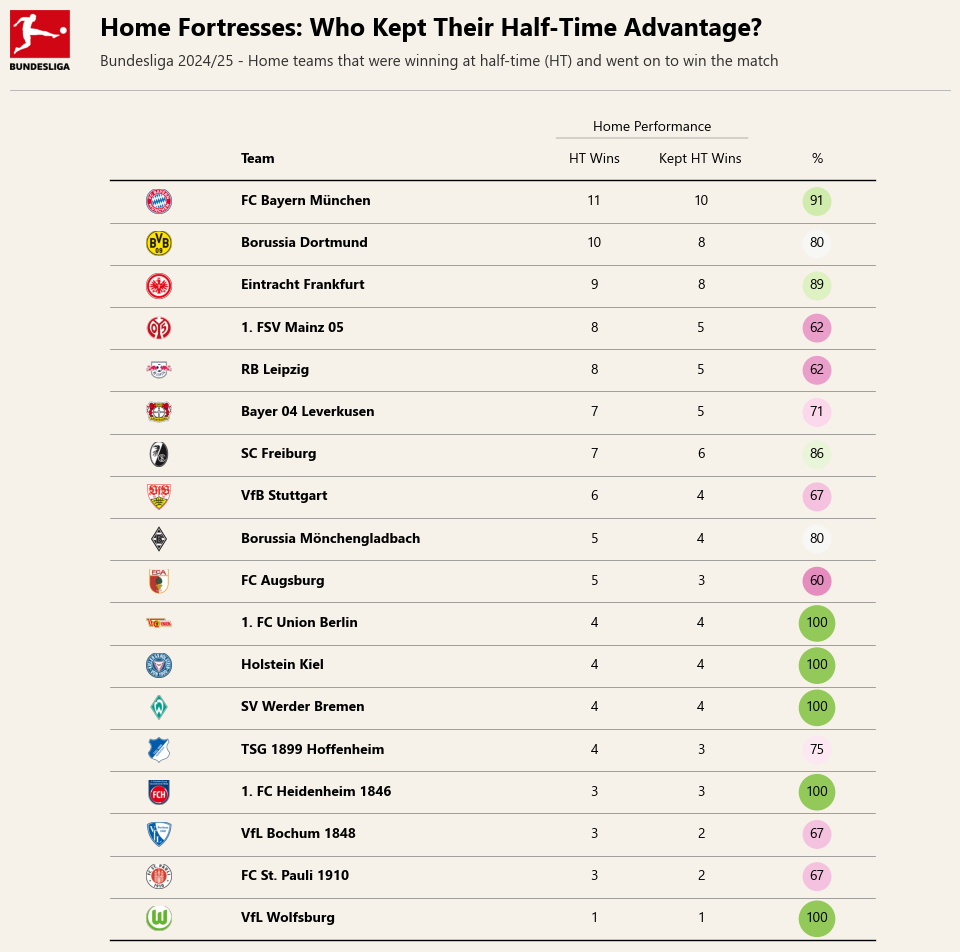

In [36]:
fn.plot_table(df = df_bundesliga_home_stats[["homeTeam.crest", "homeTeam.name", "halfTime_wins", "kept_home_wins", "%_kept_home_wins"]],
              index_col = "homeTeam.crest",
              column_definitions = col_defs_home_stats,
              title = "Home Fortresses: Who Kept Their Half-Time Advantage?",
              subtitle = "Bundesliga 2024/25 - Home teams that were winning at half-time (HT) and went on to win the match",
              logo = bundesliga_metadados["competition.emblem"],
              save_png = False)

Esta tabela oferece-nos a mesma informação de forma muito mais apelativa.

Em termos absolutos, o Bayern de Munique é, sem grande surpresa, a equipa que, a jogar em casa, chegou mais vezes em vantagem ao intervalo. Ao mesmo tempo, é aquela que mais vezes conservou a vantagem. <br>
Ainda assim, quando olhamos para a percentagem de resultados mantidos, outras equipas surgem com maior destaque. O Union Berlin, Holstein Kiel, Werder Bremen, Heidenheim e Wolfsburgo venceram todos os jogos em que chegaram a vencer ao intervalo, uma demonstração de solidez a aguentar resultados. Contudo, não podemos dissociar estas percentagens dos valores absolutos, ou seja, não podemos afirmar que uma equipa é melhor a segurar vitórias em casa apenas com base na percentagem de vitórias mantidas. O Wolfsburgo, por exemplo, apenas por uma vez chegou ao intervalo a vencer um jogo realizado em casa nesta edição da Bundesliga - poderemos realmente afirmar que o Wolfsburgo foi melhor a aguentar vantagens enquanto visitado do que o Bayern, que venceu 10 dos 11 jogos em que se encontrava a vencer ao intervalo?

Talvez mais relevante (especialmente para os treinadores das equipas) do que ver quem ganha jogos em que já estava a ganhar ao intervalo poderá ser perceber quem é que acaba por não vencer as partidas em que chegou ao intervalo na frente. Pode ser um sinal de descontração, falta de concentração e/ou incapacidade tática a refletir-se num resultado final menos favorável. Neste capítulo, Leipzig e Mainz sobressaem pela negativa, tendo desperdiçado quase metade (38%) das situações em que chegaram ao meio da partida a vencer. Estugarda, Bochum e St. Pauli também se destacam, tendo vencido apenas 67% dos jogos em que, jogando em casa, se encontravam em situação de vantagem ao intervalo.

Avancemos então para a segunda questão em análise.

### <font color='#1c8a23'>3.2. Virar Resultados na Segunda Parte</font> <a class="anchor" id="virar"></a>
[Regressar ao Índice](#toc)

Agora, queremos saber quais as equipas que foram capazes de contrariar resultados desfavoráveis ao intervalo e vencer as suas partidas. Primeiro, vamos criar duas colunas (três na verdade, uma delas auxiliar com o logo da equipa) para identificar as equipas que estavam a perder ao intervalo e as que ganharam no final do encontro.

In [37]:
# Criar coluna auxiliar com o nome da equipa a perder ao intervalo
df_bundesliga["halfTime_loser"] = np.select(
    [df_bundesliga["score.halfTime.winner"] == "HOME_TEAM", df_bundesliga["score.halfTime.winner"] == "AWAY_TEAM"],
    [df_bundesliga["awayTeam.name"], df_bundesliga["homeTeam.name"]],
    default = np.nan
)

# Vamos precisar também do emblema da equipa que estava a perder ao intervalo para as visualizações
df_bundesliga["halfTime_loser_crest"] = np.select(
    [df_bundesliga["score.halfTime.winner"] == "HOME_TEAM", df_bundesliga["score.halfTime.winner"] == "AWAY_TEAM"],
    [df_bundesliga["awayTeam.crest"], df_bundesliga["homeTeam.crest"]],
    default = np.nan
)

df_bundesliga["halfTime_loser"].value_counts()

halfTime_loser
Holstein Kiel               21
TSG 1899 Hoffenheim         17
1. FC Heidenheim 1846       17
VfL Bochum 1848             16
VfL Wolfsburg               13
1. FC Union Berlin          13
FC St. Pauli 1910           12
SV Werder Bremen            11
1. FSV Mainz 05             11
Borussia Mönchengladbach    10
Borussia Dortmund           10
FC Augsburg                 10
SC Freiburg                  9
VfB Stuttgart                8
RB Leipzig                   8
Bayer 04 Leverkusen          6
Eintracht Frankfurt          5
FC Bayern München            3
Name: count, dtype: int64

In [38]:
# Criar coluna auxiliar com o nome da equipa que ganhou o jogo
df_bundesliga["fullTime_winner"] = np.select(
    [df_bundesliga["score.fullTime.winner"] == "HOME_TEAM", df_bundesliga["score.fullTime.winner"] == "AWAY_TEAM"],
    [df_bundesliga["homeTeam.name"], df_bundesliga["awayTeam.name"]],
    default = np.nan
)
df_bundesliga["fullTime_winner"].value_counts()

fullTime_winner
FC Bayern München           25
Bayer 04 Leverkusen         19
Borussia Dortmund           17
Eintracht Frankfurt         17
SC Freiburg                 16
1. FSV Mainz 05             14
SV Werder Bremen            14
VfB Stuttgart               14
RB Leipzig                  13
Borussia Mönchengladbach    13
VfL Wolfsburg               11
FC Augsburg                 11
1. FC Union Berlin          10
1. FC Heidenheim 1846        8
FC St. Pauli 1910            8
TSG 1899 Hoffenheim          7
Holstein Kiel                6
VfL Bochum 1848              6
Name: count, dtype: int64

Perfeito. Agora, podemos criar uma variável binária para identificar se houve reviravolta no marcador e a equipa que perdia ao intervalo venceu a partida.

In [39]:
# Criar coluna binária para indicar se a equipa que estava a perder ao intervalo fez uma reviravolta e ganhou o jogo
df_bundesliga["comeback"] = (df_bundesliga["halfTime_loser"] == df_bundesliga["fullTime_winner"])

E, tal, como fizemos antes, podemos agrupar esta informação num dataset por equipa, em que contabilizamos o número de "derrotas" de cada uma ao intervalo e o número de reviravoltas que conseguiram operar.

In [40]:
df_bundesliga_comebacks = (
    df_bundesliga.dropna(subset = ["halfTime_loser"]).groupby(["halfTime_loser", "halfTime_loser_crest"]).agg(
        halfTime_losses = ("halfTime_loser", "count"),
        comebacks = ("comeback", "sum")
    )
    .reset_index()
)
df_bundesliga_comebacks.head()

,halfTime_loser,halfTime_loser_crest,halfTime_losses,comebacks
0,1. FC Heidenheim 1846,https://crests.football-data.org/44.png,17,0
1,1. FC Union Berlin,https://crests.football-data.org/28.png,13,2
2,1. FSV Mainz 05,https://crests.football-data.org/15.png,11,1
3,Bayer 04 Leverkusen,https://crests.football-data.org/3.png,6,2
4,Borussia Dortmund,https://crests.football-data.org/4.png,10,1


In [41]:
# Obter percentagem de reviravoltas (em relação ao número de vezes em que a equipa esteve a perder ao intervalo)
df_bundesliga_comebacks["%_comebacks"] = np.round(((df_bundesliga_comebacks["comebacks"] / df_bundesliga_comebacks["halfTime_losses"])) * 100, 0).astype("uint8")
df_bundesliga_comebacks.sort_values("halfTime_losses", ascending = False, inplace = True)
df_bundesliga_comebacks.reset_index(drop = True, inplace = True)
df_bundesliga_comebacks.head()

,halfTime_loser,halfTime_loser_crest,halfTime_losses,comebacks,%_comebacks
0,Holstein Kiel,https://crests.football-data.org/720.png,21,0,0
1,1. FC Heidenheim 1846,https://crests.football-data.org/44.png,17,0,0
2,TSG 1899 Hoffenheim,https://crests.football-data.org/2.png,17,1,6
3,VfL Bochum 1848,https://crests.football-data.org/36.png,16,1,6
4,1. FC Union Berlin,https://crests.football-data.org/28.png,13,2,15


Maravilha. Mais uma vez, já temos tudo o que precisamos para retirar conclusões. Vamos fazer o mesmo que para o caso anterior, e apresentar a tabela de forma mais visualmente apelativa antes de a analisar.

In [42]:
# Definir as colunas da tabela e respetivas propriedades
col_defs_comebacks = [
    ColumnDefinition(
        name = "halfTime_loser",
        title = "Team",
        textprops = {"ha": "left", "weight": "bold"},
        width = 1.75
    ),
    ColumnDefinition(
        name = "halfTime_loser_crest",
        title = "Crest",
        textprops = {"ha": "center", "va": "center", "color": bg_color},
        width = 0.5,
        plot_fn = fn.image_from_url
    ),
    ColumnDefinition(
        name = "halfTime_losses",
        title = "HT Losses",
        textprops = {"ha": "center", "color": text_color},
        width = 0.5
    ),
    ColumnDefinition(
        name = "comebacks",
        title = "Number",
        textprops = {"ha": "center", "color": text_color},
        group = "Comebacks",
        width = 0.6
    ),
    ColumnDefinition(
        name = "%_comebacks",
        title = "%",
        textprops = {"ha": "center", "bbox": {"boxstyle": "circle,pad=0.45"}},
        cmap = normed_cmap(df_bundesliga_comebacks["%_comebacks"], cmap = matplotlib.colormaps["PiYG"]),
        group = "Comebacks",
        width = 0.6
    )
]

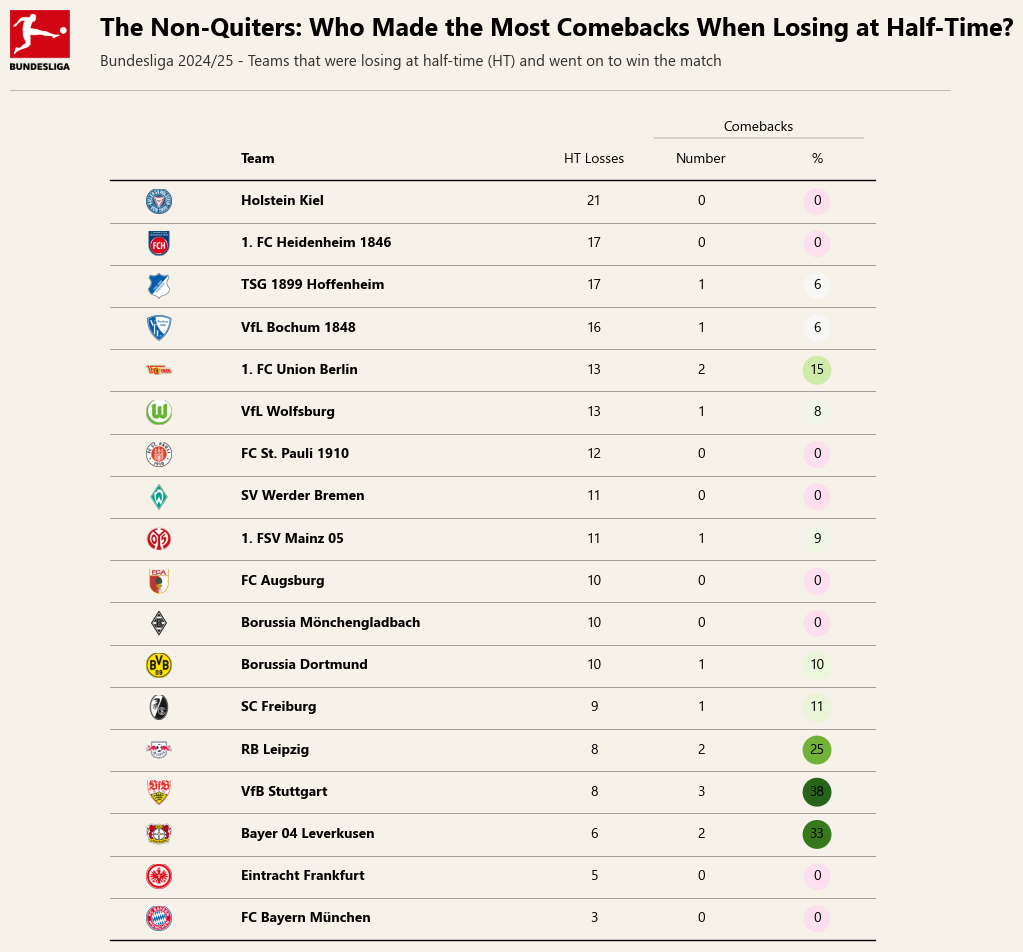

In [43]:
fn.plot_table(df = df_bundesliga_comebacks[["halfTime_loser_crest", "halfTime_loser", "halfTime_losses", "comebacks", "%_comebacks"]],
              index_col = "halfTime_loser_crest",
              column_definitions = col_defs_comebacks,
              title = "The Non-Quiters: Who Made the Most Comebacks When Losing at Half-Time?",
              subtitle = "Bundesliga 2024/25 - Teams that were losing at half-time (HT) and went on to win the match",
              logo = bundesliga_metadados["competition.emblem"],
              save_png = False)

Nesta época, o Estugarda foi o rei das reviravoltas, tanto em valor absoluto como percentualmente. Tendo chegado ao intervalo em desvantagem por 8 vezes (o 4º melhor registo da liga), em 3 delas (38%) conseguiram reverter o resultado para chegar à vitória. Leipzig, Leverkusen e Union Berlin também apresentam valores interessantes, com 2 reviravoltas cada uma.

O Holstein Kiel, por sua vez, foi a equipa que mais vezes foi para intervalo a perder (21), e em nenhuma delas conseguiu levar os 3 pontos no final da partida. Este foi, aliás, o cenário mais comum em toda a Bundesliga 24/25. Observando os valores da tabela, constatamos que a larga maioria das equipas conseguiu no máximo 1 reviravolta após estar a perder ao intervalo - sendo uma liga tão competitiva e com uma média tão interessante de golos marcados por jogo, poderíamos eventualmente esperar um número maior de reviravoltas do que aquele que se verificou.

Dar nota também que o Bayern de Munique, embora apenas por 3 vezes se tenha encontrado em desvantagem no final dos primeiros 45 minutos, em nenhum destes jogos foi capaz de chegar à vitória no encontro.

# <font color="#1c8a23">___________________________________________</font>
## <font color='#4b4b4b'>4. Bónus - Comparação com Classificação Final</font> <a class="anchor" id="bonus"></a>
[Regressar ao Índice](#toc)

Como acrescento, podemos ver como a classificação das duas estatísticas que acabámos de calcular se relaciona com a classificação final da Bundesliga. Vamos ignorar que podíamos chamar novamente a API com o uri `http://api.football-data.org/v4/competitions/2002/standings?season=2024&matchday=34` e utilizar os dados que já temos para calcular a classificação final da liga.

In [44]:
df_bundesliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     306 non-null    uint32        
 1   matchday               306 non-null    uint8         
 2   homeTeam.id            306 non-null    uint16        
 3   homeTeam.name          306 non-null    object        
 4   homeTeam.shortName     306 non-null    object        
 5   homeTeam.tla           306 non-null    object        
 6   homeTeam.crest         306 non-null    object        
 7   awayTeam.id            306 non-null    uint16        
 8   awayTeam.name          306 non-null    object        
 9   awayTeam.shortName     306 non-null    object        
 10  awayTeam.tla           306 non-null    object        
 11  awayTeam.crest         306 non-null    object        
 12  score.fullTime.winner  306 non-null    object        
 13  score

Neste momento, cada linha do dataset é um jogo específico, mas cada jogo tem duas equipas e, agora, ambas são relevantes para calcularmos os pontos que cada uma levou no final da partida. Por isso, vamos criar um dataset específico para as equipas a jogar em casa, outro para as equipas a jogar fora, e no final juntamos os dois para chegar a uma tabela em que cada linha será a performance de uma equipa num determinado jogo. A partir daí, será muito mais simples obter a pontuação final.

In [45]:
# Dataset para as equipas a jogar em casa (vamos manter os golos marcados e sofridos para apresentar depois uma tabela mais completa)
df_bundesliga_home_teams = df_bundesliga[["homeTeam.name", "homeTeam.crest", "score.fullTime.home", "score.fullTime.away"]].copy()
df_bundesliga_home_teams["result"] = np.select(
    [df_bundesliga_home_teams["score.fullTime.home"] > df_bundesliga_home_teams["score.fullTime.away"],
     df_bundesliga_home_teams["score.fullTime.home"] < df_bundesliga_home_teams["score.fullTime.away"]],
    ["W", "L"],
    default = "D"
)
df_bundesliga_home_teams["points"] = np.select(
    [df_bundesliga_home_teams["score.fullTime.home"] > df_bundesliga_home_teams["score.fullTime.away"],
     df_bundesliga_home_teams["score.fullTime.home"] < df_bundesliga_home_teams["score.fullTime.away"]],
    [3, 0],
    default = 1
)
df_bundesliga_home_teams.rename(columns = {"homeTeam.name": "team",
                                           "homeTeam.crest": "crest",
                                           "score.fullTime.home": "goals_for",
                                           "score.fullTime.away": "goals_against"}, inplace = True)

# Dataset para as equipas a jogar fora
df_bundesliga_away_teams = df_bundesliga[["awayTeam.name", "awayTeam.crest", "score.fullTime.away", "score.fullTime.home"]].copy()
df_bundesliga_away_teams["result"] = np.select(
    [df_bundesliga_away_teams["score.fullTime.home"] < df_bundesliga_away_teams["score.fullTime.away"],
     df_bundesliga_away_teams["score.fullTime.home"] > df_bundesliga_away_teams["score.fullTime.away"]],
    ["W", "L"],
    default = "D"
)
df_bundesliga_away_teams["points"] = np.select(
    [df_bundesliga_away_teams["score.fullTime.home"] < df_bundesliga_away_teams["score.fullTime.away"],
     df_bundesliga_away_teams["score.fullTime.home"] > df_bundesliga_away_teams["score.fullTime.away"]],
    [3, 0],
    default = 1
)
df_bundesliga_away_teams.rename(columns = {"awayTeam.name": "team",
                                           "awayTeam.crest": "crest",
                                           "score.fullTime.away": "goals_for",
                                           "score.fullTime.home": "goals_against"}, inplace = True)

In [46]:
df_bundesliga_teams = pd.concat([df_bundesliga_home_teams, df_bundesliga_away_teams], ignore_index = True)
display(df_bundesliga_teams.head()), display(df_bundesliga_teams.tail())

,team,crest,goals_for,goals_against,result,points
0,Borussia Mönchengladbach,https://crests.football-data.org/18.png,2,3,L,0
1,RB Leipzig,https://crests.football-data.org/721.png,1,0,W,3
2,TSG 1899 Hoffenheim,https://crests.football-data.org/2.png,3,2,W,3
3,SC Freiburg,https://crests.football-data.org/17.png,3,1,W,3
4,FC Augsburg,https://crests.football-data.org/16.png,2,2,D,1


,team,crest,goals_for,goals_against,result,points
607,SV Werder Bremen,https://crests.football-data.org/12.png,4,1,W,3
608,VfL Wolfsburg,https://crests.football-data.org/11.png,1,0,W,3
609,1. FC Union Berlin,https://crests.football-data.org/28.png,2,1,W,3
610,VfL Bochum 1848,https://crests.football-data.org/36.png,2,0,W,3
611,Holstein Kiel,https://crests.football-data.org/720.png,0,3,L,0


(None, None)

Parece tudo bem feito. Agora, podemos agregar a performance por equipa (e respetivo logo), criar uma coluna extra com a diferença de golos, e ordenar por pontos, diferença de golos, e golos marcados (os 3 primeiros critérios nesta liga).

In [47]:
df_bundesliga_table = (
    df_bundesliga_teams.groupby(["team", "crest"]).agg(
        games_played = ("team", "count"),
        goals_for = ("goals_for", lambda x: x.astype(int).sum()), # o data type era "uint8" -> pouco adequado para depois calcular a diferença de golos
        goals_against = ("goals_against", lambda x: x.astype(int).sum()), # igual para os golos sofridos
        wins = ("result", lambda x: (x == "W").sum()),
        draws = ("result", lambda x: (x == "D").sum()),
        losses = ("result", lambda x: (x == "L").sum()),
        points = ("points", "sum")
    )
    .reset_index()
)
df_bundesliga_table["goal_difference"] = df_bundesliga_table["goals_for"] - df_bundesliga_table["goals_against"]

df_bundesliga_table.sort_values(["points", "goal_difference", "goals_for"], ascending = False, inplace = True)
df_bundesliga_table.reset_index(drop = True, inplace = True)
df_bundesliga_table

,team,crest,games_played,goals_for,goals_against,wins,draws,losses,points,goal_difference
0,FC Bayern München,https://crests.football-data.org/5.png,34,99,32,25,7,2,82,67
1,Bayer 04 Leverkusen,https://crests.football-data.org/3.png,34,72,43,19,12,3,69,29
2,Eintracht Frankfurt,https://crests.football-data.org/19.png,34,68,46,17,9,8,60,22
3,Borussia Dortmund,https://crests.football-data.org/4.png,34,71,51,17,6,11,57,20
4,SC Freiburg,https://crests.football-data.org/17.png,34,49,53,16,7,11,55,-4
5,1. FSV Mainz 05,https://crests.football-data.org/15.png,34,55,43,14,10,10,52,12
6,RB Leipzig,https://crests.football-data.org/721.png,34,53,48,13,12,9,51,5
7,SV Werder Bremen,https://crests.football-data.org/12.png,34,54,57,14,9,11,51,-3
8,VfB Stuttgart,https://crests.football-data.org/10.png,34,64,53,14,8,12,50,11
9,Borussia Mönchengladbach,https://crests.football-data.org/18.png,34,55,57,13,6,15,45,-2


Novamente, já temos a tabela, mas podemos torná-la mais bonita. Aqui até podemos usar um dos [exemplos](https://plottable.readthedocs.io/en/latest/example_notebooks/bohndesliga_table.html) da documentação do plottable para nos ajudar, que também cria uma visualização com a tabela da Bundesliga.

In [48]:
# Criar coluna auxiliar para a posição na tabela (rank)
df_bundesliga_table["rank"] = df_bundesliga_table.index + 1

In [49]:
# Cores para aplicar na tabela
row_colors = {
    "top4": "#8fd1fd",
    "top5": "#FAE0C3",
    "top6": "#C7E7C8",
    "playoffs": "#F8C7C7",
    "relegation": "#f89696",
    "even": "#FFFFFF",
    "odd": "#f3f3f3",
}

bg_color_standings = row_colors["odd"]
text_color_standings = "#000000"

In [50]:
# Definir as colunas da tabela e respetivas propriedades
col_defs_standings = [
    ColumnDefinition("rank", title = "", textprops = {"ha": "center", "weight": "bold"}, width = 0.5),
    ColumnDefinition("crest", title = "", textprops = {"ha": "center", "va": "center", "color": bg_color_standings}, width = 0.4, plot_fn = fn.image_from_url),
    ColumnDefinition("team", title = "", textprops = {"ha": "left"}, width = 2.5),
    ColumnDefinition("games_played", title = "P", textprops = {"ha": "center"}, width = 0.5),
    ColumnDefinition("wins", title = "W", textprops = {"ha": "center"}, width = 0.5),
    ColumnDefinition("draws", title = "D", textprops = {"ha": "center"}, width = 0.5),
    ColumnDefinition("losses", title = "L", textprops = {"ha": "center"}, width = 0.5),
    ColumnDefinition("goals_for", title = "For", textprops = {"ha": "center"}, group = "Goals", width = 0.5),
    ColumnDefinition("goals_against", title = "Against", textprops = {"ha": "center"}, group = "Goals", width = 0.5),
    ColumnDefinition("goal_difference", title = "+/-", textprops = {"ha": "center"}, group = "Goals", formatter="{:+}", width = 0.5),
    ColumnDefinition("points", title = "Pts", textprops = {"ha": "center", "weight": "bold"}, width = 0.5)
]

Text(0.12, 0.93, 'Bundesliga 2024/25 Standings')

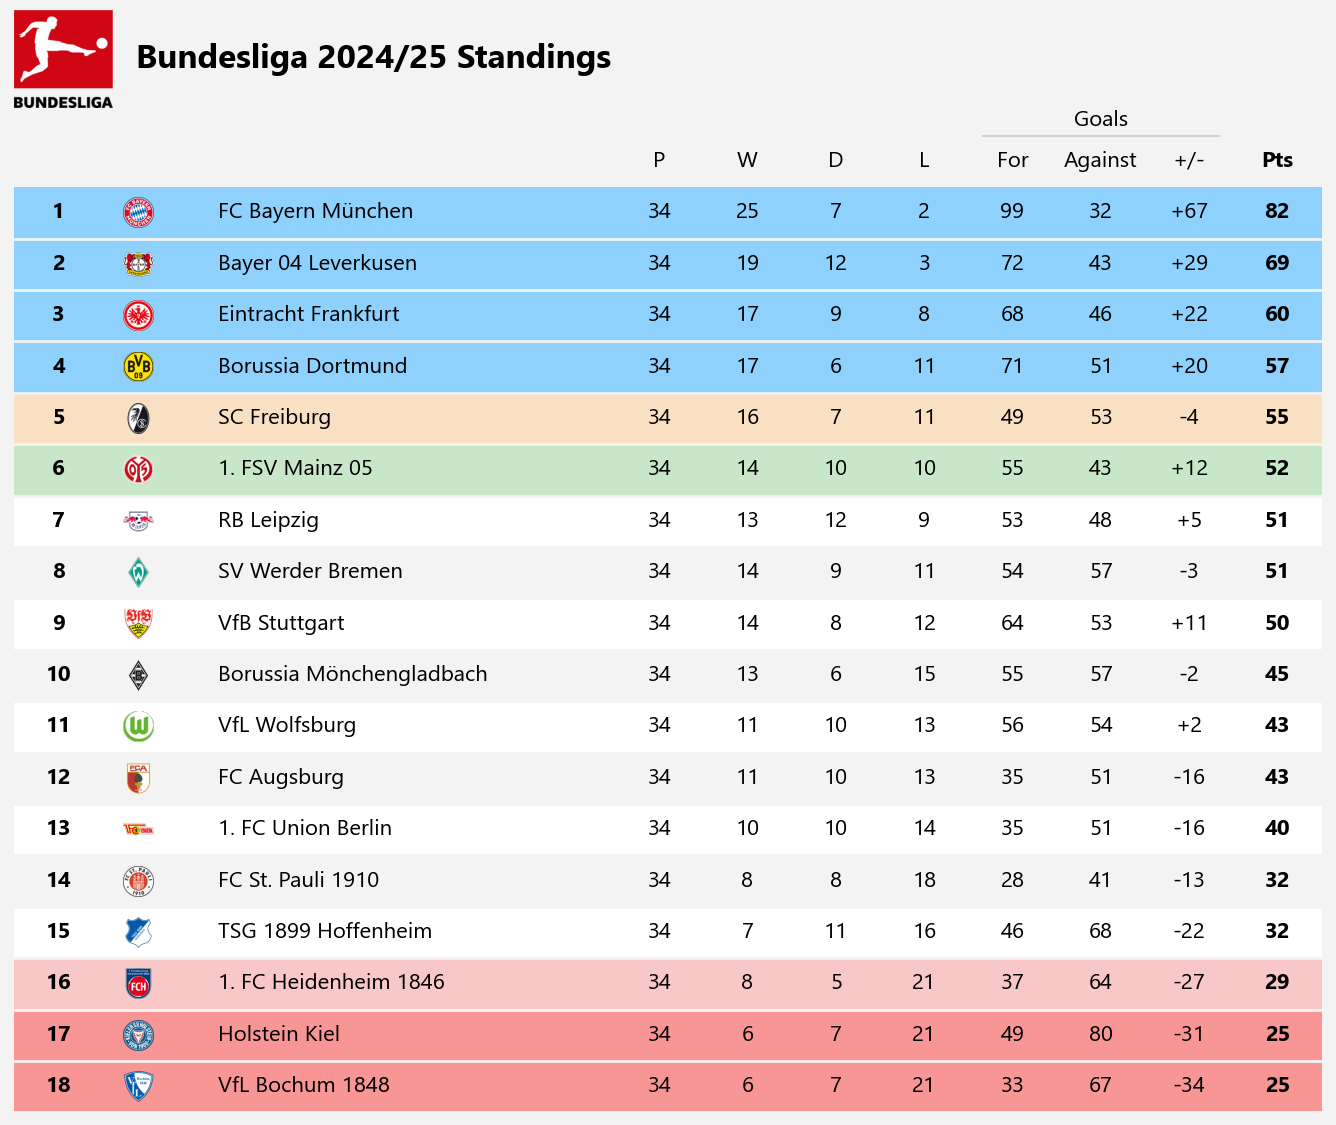

In [51]:
fig, ax = plt.subplots(figsize = (14, 12))
ax.set_axis_off()
ax.set_position([0.03, 0.05, 0.94, 0.86])
fig.set_facecolor(bg_color_standings)
ax.set_facecolor(bg_color_standings)

plt.rcParams["text.color"] = text_color_standings
df_bundesliga_table_columns = ["crest", "team", "games_played", "wins", "draws", "losses", "goals_for", "goals_against", "goal_difference", "points"]

table_standings = Table(
    df_bundesliga_table,
    column_definitions = col_defs_standings,
    row_dividers = True,
    col_label_divider = False,
    footer_divider = True,
    index_col = "rank",
    columns = df_bundesliga_table_columns,
    even_row_color = row_colors["even"],
    footer_divider_kw = {"color": bg_color_standings, "lw": 2},
    row_divider_kw = {"color": bg_color_standings, "lw": 2},
    column_border_kw = {"color": bg_color_standings, "lw": 2},
    textprops = {"fontsize": 16, "ha": "center"},
)

for idx in [0, 1, 2, 3]:
    table_standings.rows[idx].set_facecolor(row_colors["top4"])
table_standings.rows[4].set_facecolor(row_colors["top5"])
table_standings.rows[5].set_facecolor(row_colors["top6"])    
table_standings.rows[15].set_facecolor(row_colors["playoffs"])
for idx in [16, 17]:
    table_standings.rows[idx].set_facecolor(row_colors["relegation"])

with urllib.request.urlopen(bundesliga_metadados["competition.emblem"]) as url:
    logo_img = Image.open(url).convert("RGBA")
logo_ax = fig.add_axes([0.033, 0.88, 0.07, 0.10])
logo_ax.imshow(logo_img)
logo_ax.axis("off")

fig.text(
    0.12, 0.93,
    "Bundesliga 2024/25 Standings",
    fontsize = 24,
    fontweight = "bold",
    ha = "left",
    va = "center",
    color = text_color_standings
)

#fig.savefig("Bundesliga Standings.png", facecolor = fig.get_facecolor(), dpi = 200)

Já temos uma tabela mais apresentável, com a classificação e performance detalhada das equipas, e com as cores a indicar o seu destino no final da época. O campeão Bayern, Bayer Leverkusen, Eintracht Frankfurt e Borussia Dortmund apuraram-se para a Liga dos Campeões, enquanto o Friburgo seguiu para a Liga Europa e o Mainz para a Conference League. Por outro lado, Holstein Kiel e Bochum desceram de divisão, enquanto o Heidenheim teve de jogar um playoff com o terceiro classificado da Bundesliga 2 (acabou por se superiorizar ao Elversberg para garantir a manutenção).

Agora, podemos juntar todos estes rankings e explorar a relação entre a percentagem de vitórias mantidas a jogar em casa, a percentagem de reviravoltas, e a classificação final da liga. Para isso, vamos criar um bump chart recorrendo à biblioteca matplotlib.

In [52]:
# Começamos por criar um novo DataFrame com informação dos 3 rankings que queremos analisar
df_ranks = (
    df_bundesliga_table[["team", "crest", "rank"]]
    .rename(columns = {"rank": "standings"})
    .merge(
        df_bundesliga_home_stats[["homeTeam.name", "%_kept_home_wins"]],
        left_on = "team",
        right_on = "homeTeam.name"
    )
    .merge(
        df_bundesliga_comebacks[["halfTime_loser", "%_comebacks"]],
        left_on = "team",
        right_on = "halfTime_loser"
    )
)

# Aqui calculamos efetivamente os rankings para a percentagem de vitórias mantidas em casa e para a percentagem de reviravoltas
df_ranks["rank_kept_home_wins"] = (df_ranks["%_kept_home_wins"].rank(ascending = False, method = "first")).astype(int)
df_ranks["rank_comebacks"] = (df_ranks["%_comebacks"].rank(ascending = False, method = "first")).astype(int)

df_ranks = df_ranks[["team", "crest", "rank_kept_home_wins", "standings", "rank_comebacks"]]
df_ranks.head()

,team,crest,rank_kept_home_wins,standings,rank_comebacks
0,FC Bayern München,https://crests.football-data.org/5.png,6,1,11
1,Bayer 04 Leverkusen,https://crests.football-data.org/3.png,12,2,2
2,Eintracht Frankfurt,https://crests.football-data.org/19.png,7,3,12
3,Borussia Dortmund,https://crests.football-data.org/4.png,9,4,6
4,SC Freiburg,https://crests.football-data.org/17.png,8,5,5


Para variar, vamos melhorar a informação que temos na tabela para a apresentar de forma mais visualmente apelativa. Um dos passos envolve criar um dicionário para associar cada equipa à respetiva cor principal. Esta será a cor a aplicar nas linhas, mais à frente no bump chart.

Como referências, foram consultados os seguintes sites:
* [Team Color Codes](https://teamcolorcodes.com/bundesliga/)
* [Brand Color Code](https://www.brandcolorcode.com/company/bundesliga-teams)

In [53]:
bundesliga_teams = df_ranks["team"].unique().tolist()
bundesliga_colors = ["#0066B2", "#E32221", "#000000", "#FDE100", "#000000", "#C3141E", "#0C2043", "#009655", "#D40723", "#000000", "#65B32E", "#BA3733", "#EB1923", "#3F3832", "#1961B5", "#003B79", "#003B79", "#005297", "#005BA4"]

team_colors = dict(zip(bundesliga_teams, bundesliga_colors))

Agora podemos criar a visualização em si. Para isso, vamos usar duas funções auxiliares, `draw_curve` e `add_logo_from_url`. A primeira função foi criada com ajuda da documentação do matplotlib e também do ChatGPT (há que lhe dar crédito onde merece), enquanto a segunda é uma melhoria a outra que já tínhamos utilizado anteriormente.

Text(0.12, 0.93, 'Bundesliga 2024/25 - Relationship Between Rankings')

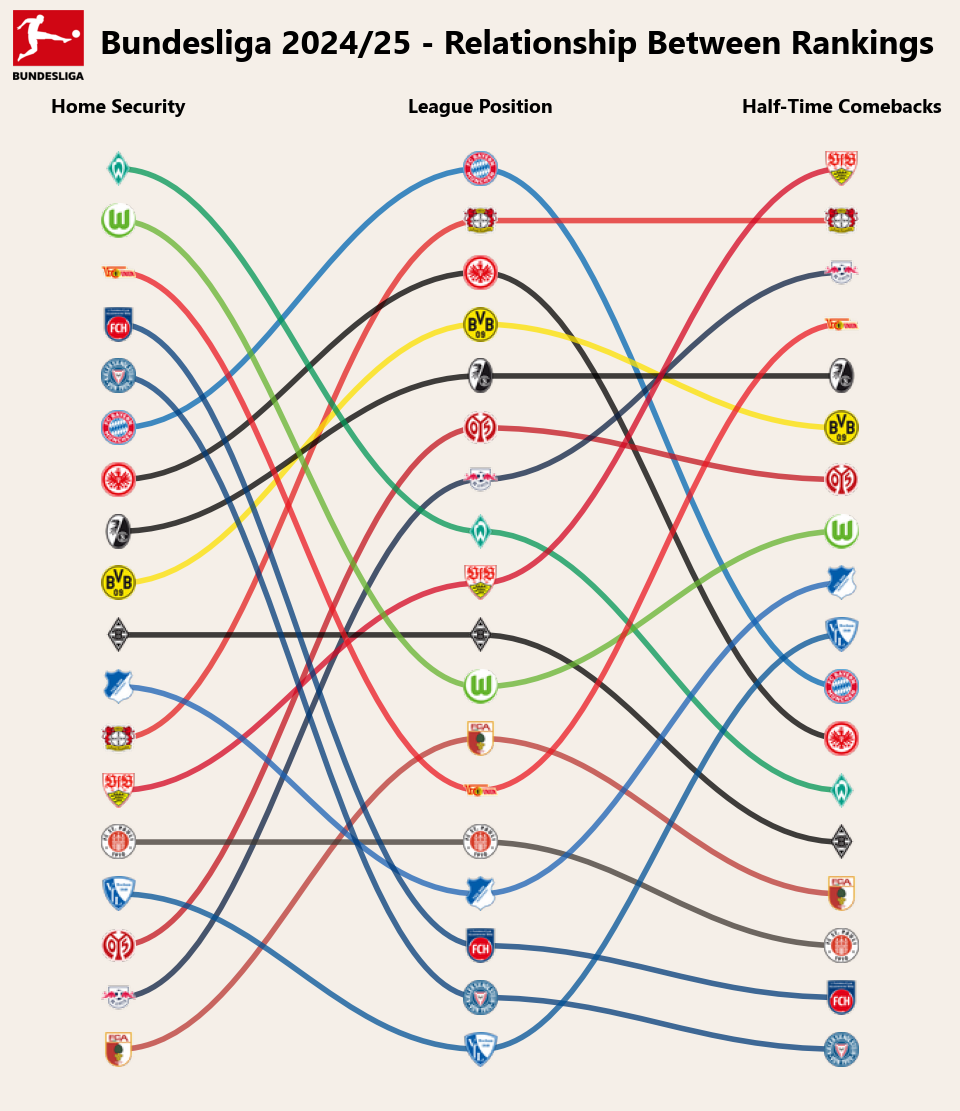

In [54]:
fig, ax = plt.subplots(figsize = (10, 12))
ax.set_axis_off()
ax.set_position([0.03, 0.05, 0.94, 0.82])
fig.set_facecolor("#F5EFE8")

ax.set_xlim(-0.3, 2.3)
ax.set_ylim(len(df_ranks) + 1, 0)

ax.axis("off")

x_positions = [0, 1, 2]
labels = ["Home Security", "League Position", "Half-Time Comebacks"]

for x, label in zip(x_positions, labels):
    ax.text(x, 0, label, ha = "center", va = "bottom", fontsize = 14, fontweight="bold")

for _, row in df_ranks.iterrows():
    team = row["team"]
    color = team_colors[team]

    xs = [0, 1, 2]
    ys = [row["rank_kept_home_wins"], row["standings"], row["rank_comebacks"]]

    # Desenhar a curva
    fn.draw_curve(ax, xs, ys, color = color)

    # Desenhar os logos
    for x, y in zip(xs, ys):
        fn.add_logo_from_url(ax, x, y, row["crest"])

with urllib.request.urlopen(bundesliga_metadados["competition.emblem"]) as url:
    logo_img = Image.open(url).convert("RGBA")
logo_ax = fig.add_axes([0.033, 0.88, 0.07, 0.10])
logo_ax.imshow(logo_img)
logo_ax.axis("off")

fig.text(
    0.12, 0.93,
    "Bundesliga 2024/25 - Relationship Between Rankings",
    fontsize = 24,
    fontweight = "bold",
    ha = "left",
    va = "center",
    color = text_color_standings
)

#fig.savefig("Relação Entre Rankings.png", facecolor = fig.get_facecolor(), dpi = 200)

Apesar de podermos inicialmente imaginar que houvesse uma relação significativa entre a percentagem de vitórias mantidas em casa e a tabela classificativa, a análise individual das métricas já deixava antever um pouco o que esta visualização acaba por comprovar. Não parece haver uma grande correlação entre as duas variáveis - quanto muito até poderia haver uma relação negativa entre a percentagem de resultados positivos mantidos em casa e a classificação final. Esta é, se quisermos retirar alguma conclusão, uma prova da imprevisibilidade e competitividade em todos os jogos da Bundesliga. <br>
Da mesma forma, a relação entre a percentagem de reviravoltas completadas e a posição ocupada no final da liga também não parece estatisticamente significativa. É verdade que, aqui, podemos observar maior tendência para as equipas da metade de baixo da tabela serem também aquelas com menor percentagem de reviravoltas conseguidas, e vice-versa. Ainda assim, podemos observar os casos extremos de Bayern e Bochum, primeiro e último do campeonato, respetivamente, e concluir que o Bochum até tem maior percentagem de reviravoltas que o campeão - suportando-nos da tabela apresentada anteriormente, o Bochum conseguiu 1 reviravolta em 16 ocasiões em que foi em desvantagem para o intervalo, enquanto o Bayern não conseguiu por nenhuma vez chegar à vitória nas 3 situações em que se encontrava a perder no fim dos primeiros 45 minutos.

Por fim, e para garantir que a interpretação que fizemos da visualização se encontra correta, podemos calcular a correlação de Spearman entre os 3 rankings. Neste caso específico, em que já estamos a comparar ranks (sem empates), calcular a correlação de Pearson ou de Spearman é equivalente, mas vamos recorrer ao segundo destes métodos, habitualmente recomendado para identificar relações monotónicas (lineares ou não) entre variáveis.

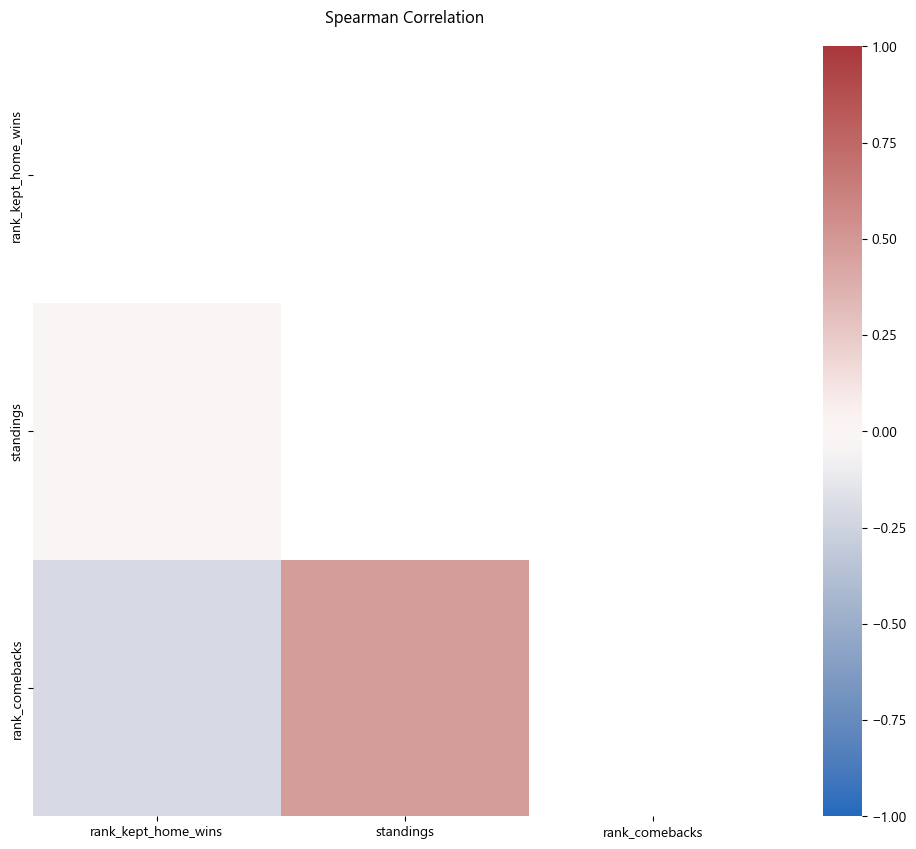

,rank_kept_home_wins,standings,rank_comebacks
rank_kept_home_wins,1.000000,-0.001032,-0.203302
standings,-0.001032,1.000000,0.471620
rank_comebacks,-0.203302,0.471620,1.000000


In [55]:
fn.spearman_correlation(df_ranks, numerical_variables = ["rank_kept_home_wins", "standings", "rank_comebacks"])

Como tínhamos antecipado, a relação entre a percentagem de vitórias mantidas em casa e a classificação final é aproximadamente nula, enquanto a relação entre a percentagem de reviravoltas e a posição no final da liga é positiva e mais forte (0.47), mas não o suficiente para ser tida como uma correlação siginificativa (habitualmente considera-se uma correlação forte a partir de um valor na ordem dos 0.7).

Interessante também observar que há uma pequena correlação negativa (-0.2) entre a percentagem de vitórias mantidas em casa e a percentagem de reviravoltas, isto é, há uma ligeira tendência para as equipas com maior percentagem de resultados positivos aguentados em casa serem piores a conseguir reviravoltas quando se encontram em situação de desvantagem ao intervalo.

Assim concluímos a análise das melhores equipas a segurar vantagens em casa na edição 2024/25 da Bundesliga e das equipas que mais reviravoltas conseguiram quando em desvantagem ao intervalo neste mesmo campeonato. Explorámos também a relação (ou ausência dela) entre estes dois indicadores e a classificação final da liga, recorrendo a visuais completos que apresentam informação detalhada, destacando ao mesmo tempo as conclusões mais relevantes. Até breve!